# Haltestellen im Verkehrsverbund Steiermark

Univariate descriptive analysis for the master's thesis.

**Sources:** cleaned annual layers in `OGD/Public_Transport/` and the original 2025 attributes in `Haltestellen_2025.zip`.

In [1]:
import os
import sys
from pathlib import Path
os.chdir(r"D:\CO2_Masterarbeit\CO2_Masterarbeit")
sys.path.insert(0, r"D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG")

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from ANAL.routing.destination_builders import yearly_transport_stops
from plotting.apa7 import set_apa7_style, new_figure, save_apa7, add_north_arrow, BAR_KWARGS, HIST_KWARGS, LINE_KWARGS

set_apa7_style()

In [2]:
clean_2025 = gpd.read_parquet("OGD/Public_Transport/public_transport_weekday_stop_frequency_2025.geoparquet")
stops = gpd.read_file("OGD/Public_Transport/Haltestellen_2025.zip")
stops["station_id"] = pd.to_numeric(stops["HNR"], errors="raise").astype("int64")
stops = stops.loc[stops["station_id"].isin(clean_2025["station_id"])].copy()
stops["Abfahrten"].describe()

count     6837.000000
mean       134.452099
std        398.107112
min          0.000000
25%          5.000000
50%         24.000000
75%         86.000000
max      10322.000000
Name: Abfahrten, dtype: float64

## Scheduled departures per stop

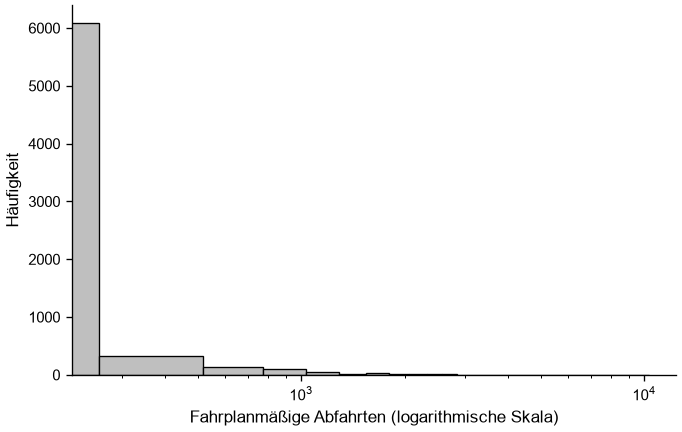

In [3]:
fig, ax = new_figure()
ax.hist(stops["Abfahrten"].dropna(), bins=40, **HIST_KWARGS)
ax.set_xscale("log")
ax.set(xlabel="Fahrplanmäßige Abfahrten (logarithmische Skala)", ylabel="Häufigkeit")
save_apa7(fig, "FIG/Haltestellen/figure_1_departures_distribution.png")
save_apa7(fig, "FIG/Haltestellen/figure_1_departures_distribution.svg")
plt.show()

## Stops by tariff zone

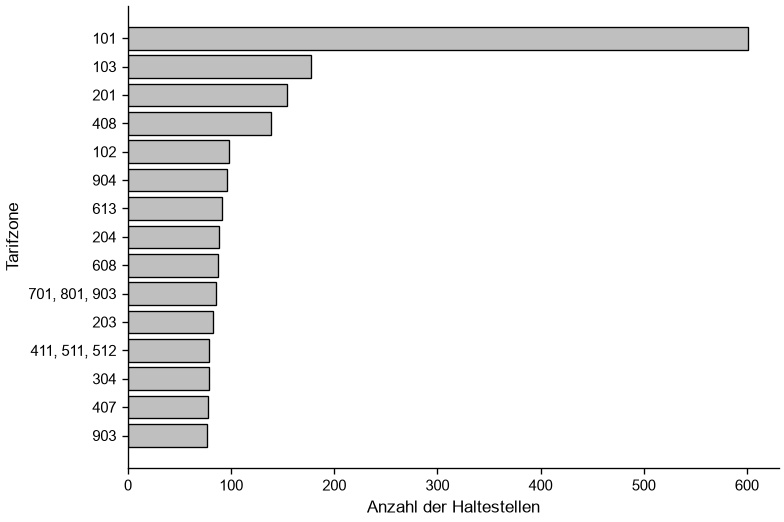

In [4]:
counts = stops["TARIFZONEN"].fillna("Fehlend").value_counts().head(15).sort_values()
fig, ax = new_figure(7, 5)
ax.barh(counts.index, counts.values, **BAR_KWARGS)
ax.set(xlabel="Anzahl der Haltestellen", ylabel="Tarifzone")
save_apa7(fig, "FIG/Haltestellen/figure_2_stops_by_tariff_zone.png")
save_apa7(fig, "FIG/Haltestellen/figure_2_stops_by_tariff_zone.svg")
plt.show()

## Historical weekday frequencies

The annual GeoParquets are prepared in `OGD/Public_Transport/Public_Transport_preparation.ipynb`. The complete 2015–2025 analytical series reads its already assigned target-year file directly; years copied from another source year are shown in gray. Legacy years use the mean of representative school and holiday schedules. GTFS years use the equal-weight mean of five complete school weekdays immediately before the Austrian autumn break and five official school-free weekdays in the following autumn-holiday period. Every GTFS layer includes a separately deduplicated ÖBB Personenverkehr supplement: observed annual ÖBB data for 2023–2025 and the earliest available 2023 ÖBB archive as an explicitly labelled proxy for the otherwise missing ÖBB service in 2021 and 2022.

In [5]:
PROJECT_DIR = Path.cwd()
years = tuple(range(2015, 2026))
yearly_datasets = {year: yearly_transport_stops(PROJECT_DIR, year) for year in years}
observed_years = tuple(
    year for year, dataset in yearly_datasets.items()
    if dataset["imputation_method"].astype(str).str.startswith("observed").all()
)
datasets = {year: yearly_datasets[year] for year in observed_years}
yearly_summary = pd.DataFrame([
    {
        "year": year,
        "stops": len(yearly_datasets[year]),
        "weekday_departures": yearly_datasets[year]["weekday_avg_departures"].sum(),
        "source_years": "/".join(sorted(dataset["frequency_source_year"].astype(str).unique())),
        "observed": dataset["imputation_method"].astype(str).str.startswith("observed").all(),
    }
    for year, dataset in yearly_datasets.items()
])
summary = pd.read_csv("OGD/Public_Transport/public_transport_weekday_frequency_summary.csv")
border = gpd.read_file("OGD/Gemeindegrenzen.zip", columns=[]).dissolve().to_crs(3857)
yearly_summary

,year,stops,weekday_departures,source_years,observed
0,2015,7561,225279.000,2017,False
1,2016,7561,225279.000,2017,False
2,2017,7561,225279.000,2017,True
3,2018,7443,217130.000,2018,True
4,2019,7425,234303.000,2019,True
5,2020,7116,238252.000,2020,True
6,2021,7110,239228.550,2021,True
7,2022,7032,268801.775,2022,True
8,2023,7020,288615.950,2023,True
9,2024,7030,277425.250,2024,True


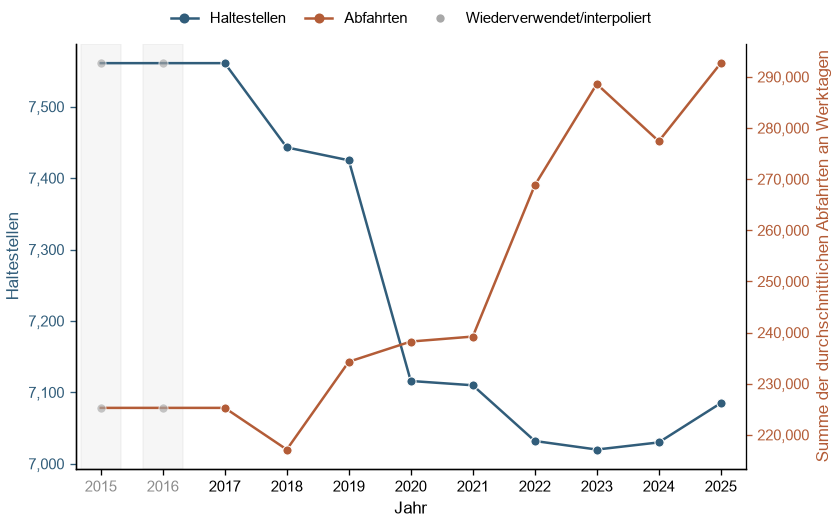

In [6]:
from matplotlib.lines import Line2D
from matplotlib.ticker import StrMethodFormatter

stop_color = "#315D7A"
departure_color = "#B35C37"
imputed_color = "#A8A8A8"
observed = yearly_summary["observed"]
imputed = ~observed

fig, ax_stops = new_figure(7.2, 4.6)
ax_departures = ax_stops.twinx()

# Subtle bands and gray markers identify years whose values come from other source years.
for year in yearly_summary.loc[imputed, "year"]:
    ax_stops.axvspan(year - 0.32, year + 0.32, color=imputed_color, alpha=0.10, zorder=0)

ax_stops.plot(
    yearly_summary["year"], yearly_summary["stops"],
    color=stop_color, linewidth=1.5, zorder=2,
)
ax_departures.plot(
    yearly_summary["year"], yearly_summary["weekday_departures"],
    color=departure_color, linewidth=1.5, zorder=2,
)

for axis, column, color in (
    (ax_stops, "stops", stop_color),
    (ax_departures, "weekday_departures", departure_color),
):
    axis.scatter(
        yearly_summary.loc[observed, "year"], yearly_summary.loc[observed, column],
        s=30, color=color, edgecolor="white", linewidth=0.6, alpha=1, zorder=4,
    )
    axis.scatter(
        yearly_summary.loc[imputed, "year"], yearly_summary.loc[imputed, column],
        s=30, color=imputed_color, edgecolor="white", linewidth=0.6, alpha=0.65, zorder=4,
    )

ax_stops.set(
    xlim=(2014.6, 2025.4), xticks=years, xlabel="Jahr", ylabel="Haltestellen",
)
ax_departures.set_ylabel("Summe der durchschnittlichen Abfahrten an Werktagen")
ax_stops.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax_departures.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax_stops.tick_params(axis="y", colors=stop_color)
ax_departures.tick_params(axis="y", colors=departure_color)
ax_stops.yaxis.label.set_color(stop_color)
ax_departures.yaxis.label.set_color(departure_color)
ax_departures.grid(False)
ax_departures.spines["top"].set_visible(False)

for label, year in zip(ax_stops.get_xticklabels(), years):
    if year not in observed_years:
        label.set_color("0.55")

legend_handles = [
    Line2D([0], [0], color=stop_color, marker="o", markersize=5, label="Haltestellen"),
    Line2D([0], [0], color=departure_color, marker="o", markersize=5, label="Abfahrten"),
    Line2D([0], [0], color="none", marker="o", markerfacecolor=imputed_color,
           markeredgecolor="white", markersize=6, label="Wiederverwendet/interpoliert"),
]
ax_stops.legend(
    handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 1.01),
    ncol=3, frameon=False, handlelength=1.8, columnspacing=1.3,
)

save_apa7(fig, "FIG/Haltestellen/figure_4_stops_and_weekday_departures_by_year.png")
save_apa7(fig, "FIG/Haltestellen/figure_4_stops_and_weekday_departures_by_year.svg")
plt.show()

### Alternative final-series view: shared-axis stacked panels

This APA-style alternative avoids a secondary vertical axis. The two monochrome panels share the same year axis, while darker background bands identify reused or interpolated years.


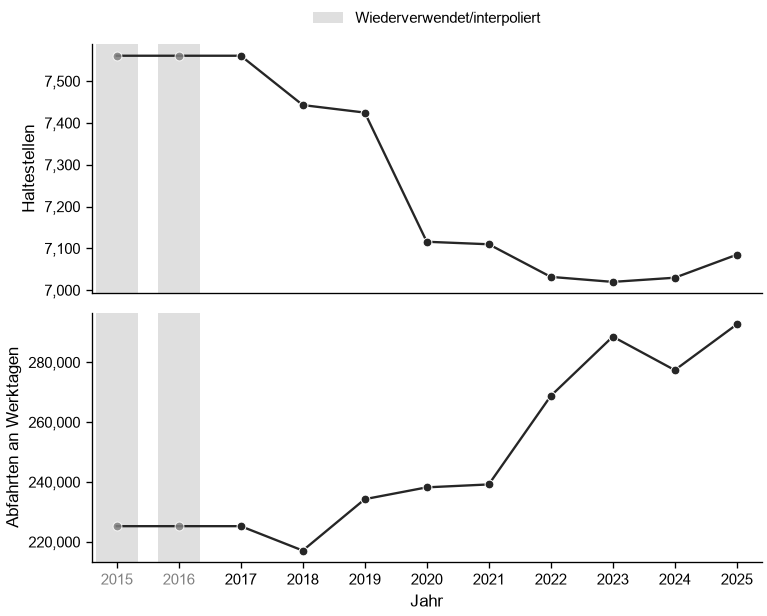

In [7]:
from matplotlib.patches import Patch

line_color = "0.15"
imputed_marker_color = "0.50"
reused_band_color = "0.68"

fig, (ax_stops_panel, ax_departures_panel) = plt.subplots(
    2, 1, figsize=(7.2, 5.6), sharex=True, gridspec_kw={"hspace": 0.08}
)
panel_specs = (
    (ax_stops_panel, "stops", "Haltestellen"),
    (ax_departures_panel, "weekday_departures", "Abfahrten an Werktagen"),
)

for axis, column, ylabel in panel_specs:
    for year in yearly_summary.loc[imputed, "year"]:
        axis.axvspan(
            year - 0.34, year + 0.34, color=reused_band_color, alpha=0.38,
            linewidth=0, zorder=0,
        )
    axis.plot(
        yearly_summary["year"], yearly_summary[column],
        color=line_color, linewidth=1.4, zorder=2,
    )
    axis.scatter(
        yearly_summary.loc[observed, "year"], yearly_summary.loc[observed, column],
        s=28, color=line_color, edgecolor="white", linewidth=0.6, alpha=1, zorder=4,
    )
    axis.scatter(
        yearly_summary.loc[imputed, "year"], yearly_summary.loc[imputed, column],
        s=28, color=imputed_marker_color, edgecolor="white", linewidth=0.6,
        alpha=0.85, zorder=4,
    )
    axis.set_ylabel(ylabel)
    axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(False)

ax_stops_panel.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
ax_departures_panel.set(
    xlim=(2014.6, 2025.4), xticks=years, xlabel="Jahr",
)
for label, year in zip(ax_departures_panel.get_xticklabels(), years):
    if year not in observed_years:
        label.set_color(imputed_marker_color)

ax_stops_panel.legend(
    handles=[Patch(facecolor=reused_band_color, alpha=0.38, edgecolor="none",
                   label="Wiederverwendet/interpoliert")],
    loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False,
)

save_apa7(fig, "FIG/Haltestellen/figure_4c_final_series_stops_and_weekday_departures_stacked.png")
save_apa7(fig, "FIG/Haltestellen/figure_4c_final_series_stops_and_weekday_departures_stacked.svg")
plt.show()


#### Visualisierte Werte

Die Tabelle enthält genau die in der Abbildung dargestellten Werte.

In [8]:
visualized_values = (
    yearly_summary.assign(
        data_status=yearly_summary["observed"].map({
            True: "Beobachtet",
            False: "Wiederverwendet/interpoliert",
        })
    )
    .rename(columns={
        "year": "Jahr",
        "stops": "Haltestellen",
        "weekday_departures": "Abfahrten an Werktagen",
        "source_years": "Quelljahr(e)",
        "data_status": "Datenstatus",
    })[["Jahr", "Haltestellen", "Abfahrten an Werktagen", "Quelljahr(e)", "Datenstatus"]]
)
display(
    visualized_values.style
    .format({"Haltestellen": "{:,.0f}", "Abfahrten an Werktagen": "{:,.2f}"})
    .hide(axis="index")
)

Jahr,Haltestellen,Abfahrten an Werktagen,Quelljahr(e),Datenstatus
2015,"7,561","225,279.00",2017,Wiederverwendet/interpoliert
2016,"7,561","225,279.00",2017,Wiederverwendet/interpoliert
2017,"7,561","225,279.00",2017,Beobachtet
2018,"7,443","217,130.00",2018,Beobachtet
2019,"7,425","234,303.00",2019,Beobachtet
2020,"7,116","238,252.00",2020,Beobachtet
2021,"7,110","239,228.55",2021,Beobachtet
2022,"7,032","268,801.78",2022,Beobachtet
2023,"7,020","288,615.95",2023,Beobachtet
2024,"7,030","277,425.25",2024,Beobachtet


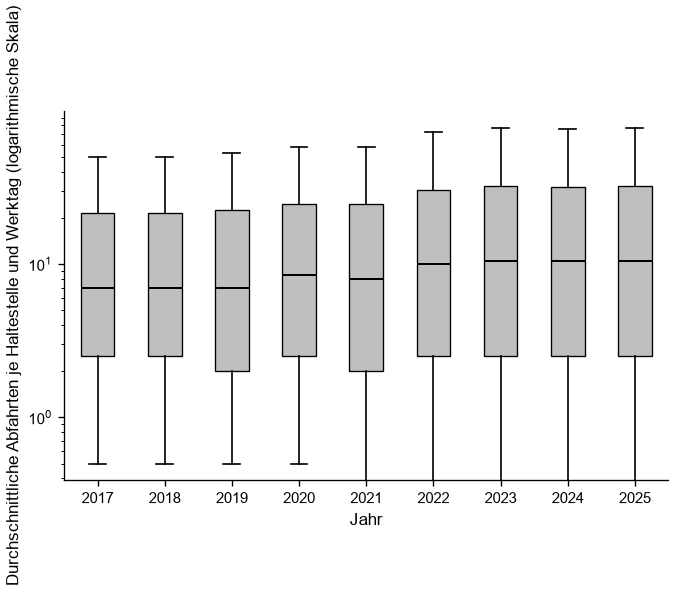

In [9]:
fig, ax = new_figure()
values = [datasets[year]["weekday_avg_departures"].dropna().to_numpy() for year in observed_years]
ax.boxplot(values, tick_labels=observed_years, showfliers=False, patch_artist=True,
           boxprops={"facecolor": "0.75", "edgecolor": "black", "linewidth": 0.8},
           medianprops={"color": "black", "linewidth": 1.2}, whiskerprops={"color": "black"}, capprops={"color": "black"})
ax.set(yscale="log", xlabel="Jahr", ylabel="Durchschnittliche Abfahrten je Haltestelle und Werktag (logarithmische Skala)")
save_apa7(fig, "FIG/Haltestellen/figure_5_average_weekday_departures_distribution_by_year.png")
save_apa7(fig, "FIG/Haltestellen/figure_5_average_weekday_departures_distribution_by_year.svg")
plt.show()

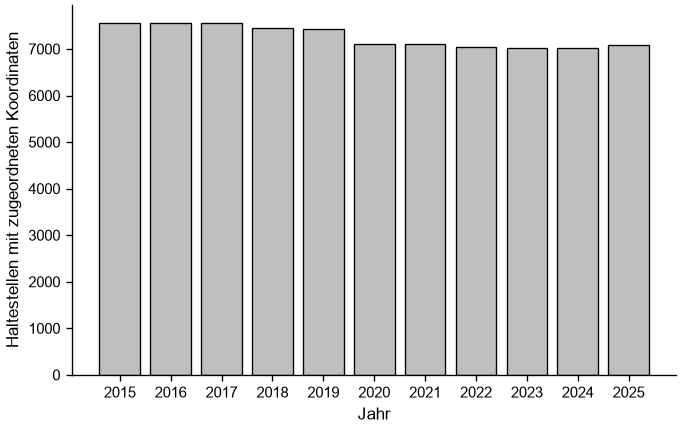

In [10]:
fig, ax = new_figure()
ax.bar(summary["year"].astype(str), summary["located_stops"], **BAR_KWARGS)
ax.set(xlabel="Jahr", ylabel="Haltestellen mit zugeordneten Koordinaten")
save_apa7(fig, "FIG/Haltestellen/figure_6_stops_with_matched_coordinates_by_year.png")
save_apa7(fig, "FIG/Haltestellen/figure_6_stops_with_matched_coordinates_by_year.svg")
plt.show()

## Spatial distribution by year

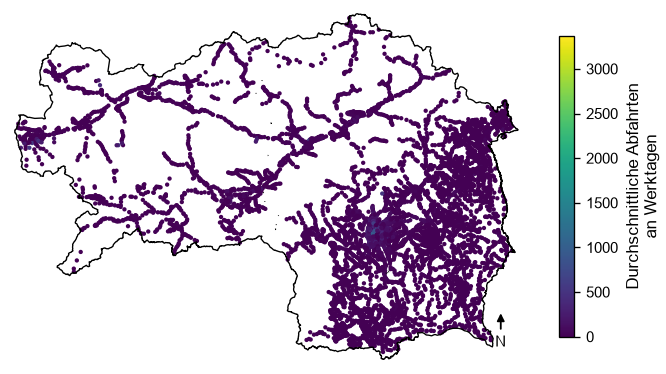

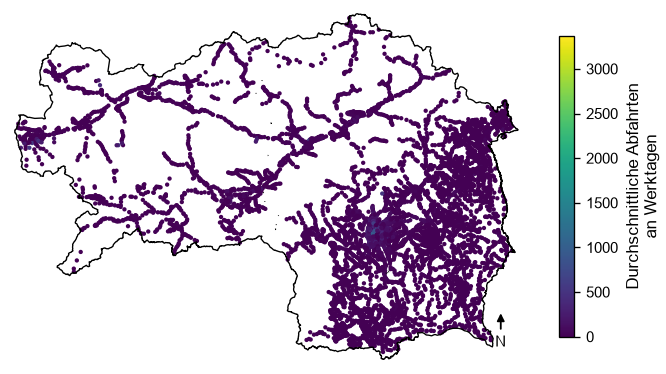

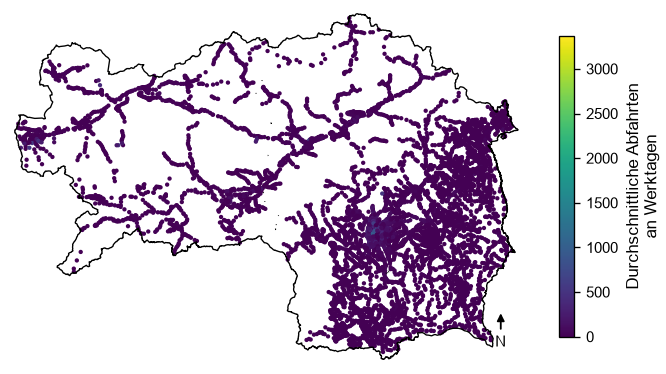

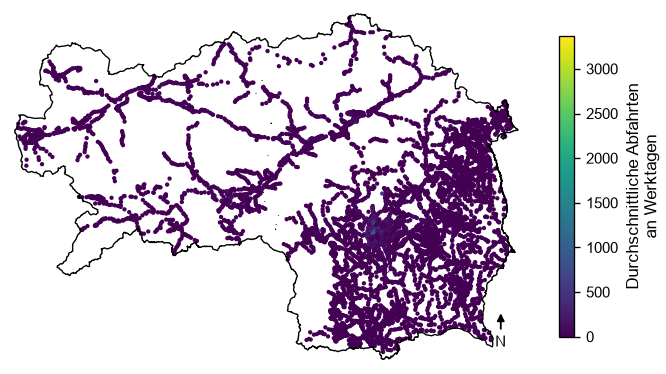

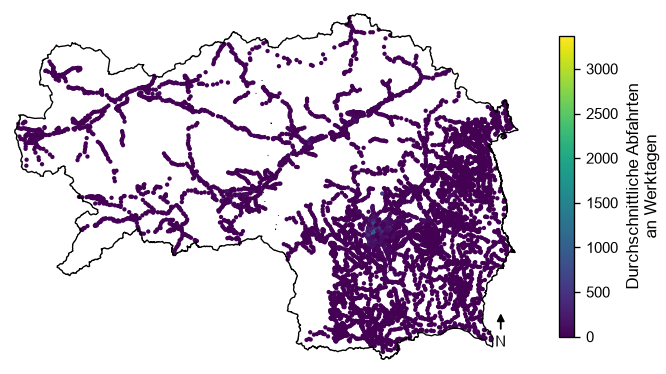

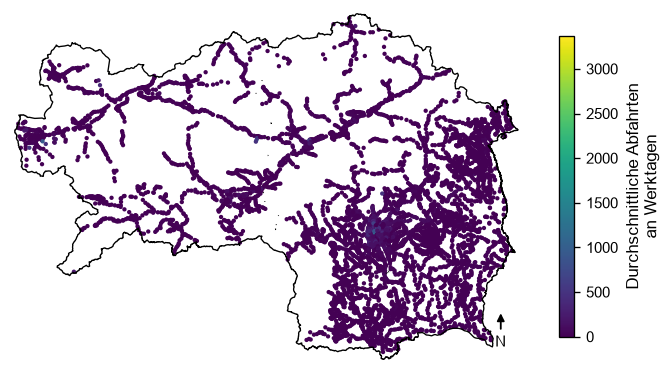

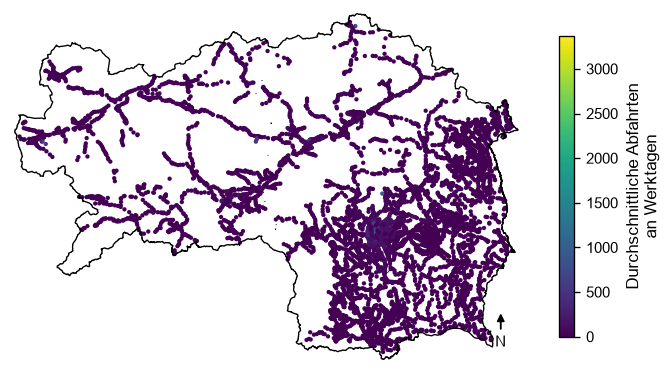

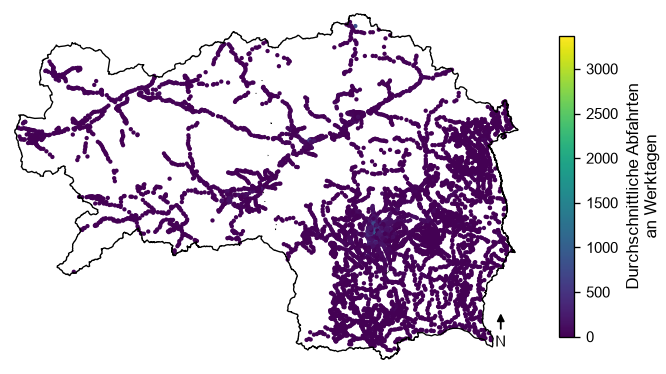

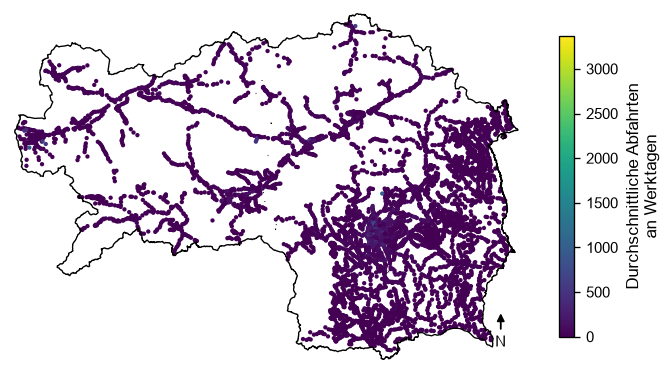

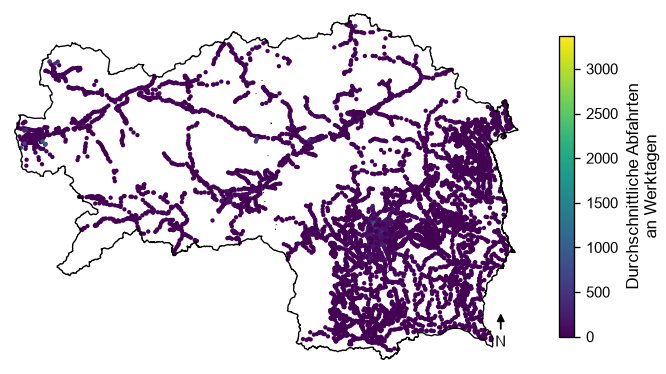

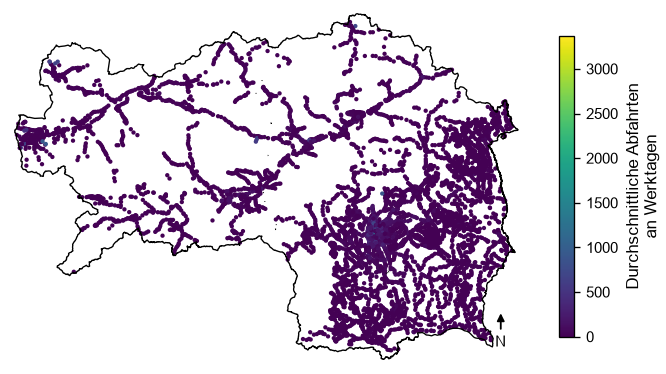

In [11]:
def map_ready_stops(dataset):
    """Project routing-ready WGS84 stops to the map CRS and enforce the Styria extent."""
    mapped = dataset.loc[dataset["location_matched"]].to_crs(border.crs).copy()
    inside = mapped.geometry.intersects(border.geometry.iloc[0])
    if not inside.all():
        outside_ids = mapped.loc[~inside, "station_id"].tolist()
        raise ValueError(f"Stops outside the Styria boundary: {outside_ids[:10]}")
    return mapped


map_xmin, map_ymin, map_xmax, map_ymax = border.total_bounds
map_padding = 5_000
max_departures = max(dataset["weekday_avg_departures"].max() for dataset in yearly_datasets.values())

for year, dataset in yearly_datasets.items():
    fig, ax = new_figure(7, 5)
    border.boundary.plot(ax=ax, color="black", linewidth=0.8)
    mapped = map_ready_stops(dataset)
    mapped.plot(ax=ax, column="weekday_avg_departures", cmap="viridis", markersize=2.5,
                                               vmin=0, vmax=max_departures, legend=True,
                                               legend_kwds={"label": "Durchschnittliche Abfahrten\nan Werktagen", "shrink": 0.65}, rasterized=True)
    ax.set(xlim=(map_xmin - map_padding, map_xmax + map_padding),
           ylim=(map_ymin - map_padding, map_ymax + map_padding))
    ax.set_aspect("equal")
    ax.set_axis_off()
    add_north_arrow(ax)
    save_apa7(fig, f"FIG/Haltestellen/figure_7_average_weekday_departures_map_{year}.png")
    save_apa7(fig, f"FIG/Haltestellen/figure_7_average_weekday_departures_map_{year}.svg")
    plt.show()

## Change between 2016 and 2022

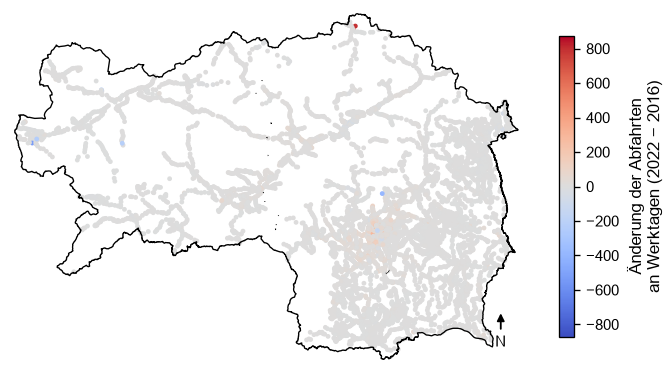

In [12]:
baseline = yearly_datasets[2016][["station_id", "weekday_avg_departures"]].rename(columns={"weekday_avg_departures": "departures_2016"})
comparison = yearly_datasets[2022].merge(baseline, on="station_id", how="inner", validate="one_to_one")
comparison["departure_change_2016_2022"] = comparison["weekday_avg_departures"] - comparison["departures_2016"]
mapped_comparison = map_ready_stops(comparison)
limit = mapped_comparison["departure_change_2016_2022"].abs().max()

fig, ax = new_figure(7, 5)
border.boundary.plot(ax=ax, color="black", linewidth=0.8)
mapped_comparison.plot(ax=ax, column="departure_change_2016_2022", cmap="coolwarm", markersize=3.5,
                                                vmin=-limit, vmax=limit, legend=True,
                                                legend_kwds={"label": "Änderung der Abfahrten\nan Werktagen (2022 − 2016)", "shrink": 0.65}, rasterized=True)
ax.set(xlim=(map_xmin - map_padding, map_xmax + map_padding),
       ylim=(map_ymin - map_padding, map_ymax + map_padding))
ax.set_aspect("equal")
ax.set_axis_off()
add_north_arrow(ax)
save_apa7(fig, "FIG/Haltestellen/figure_8_average_weekday_departures_change_2016_2022_map.png")
save_apa7(fig, "FIG/Haltestellen/figure_8_average_weekday_departures_change_2016_2022_map.svg")
plt.show()

## Station presence across all annual extracts

Figure 9 shows the union of station IDs in the 2015–2025 annual extracts. A station is classified as consistently present only when the same station ID occurs in every annual extract; otherwise it is classified as not present in every extract. Where coordinates differ between source years, the latest available geometry is used for display.

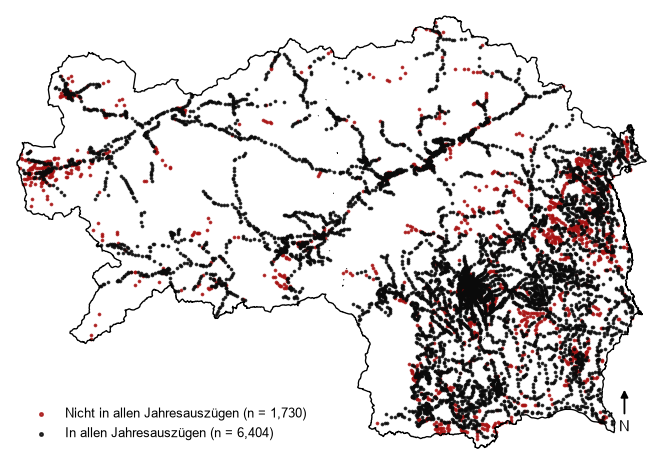

,presence_category,stations,minimum_extracts,maximum_extracts
0,Nicht in allen Jahresauszügen,1730,1,10
1,In allen Jahresauszügen,6404,11,11


In [19]:
presence_parts = []
for year, dataset in yearly_datasets.items():
    part = dataset[["station_id", "station_name", "geometry"]].copy()
    part["extract_year"] = year
    presence_parts.append(part)
station_presence_long = gpd.GeoDataFrame(
    pd.concat(presence_parts, ignore_index=True), geometry="geometry", crs=next(iter(yearly_datasets.values())).crs
)
presence_counts = station_presence_long.groupby("station_id")["extract_year"].nunique()
latest_station_geometry = (station_presence_long.sort_values("extract_year", ascending=False)
                           .drop_duplicates("station_id").copy())
latest_station_geometry["extract_count"] = latest_station_geometry["station_id"].map(presence_counts)
latest_station_geometry["presence_category"] = latest_station_geometry["extract_count"].eq(len(years)).map({
    True: "In allen Jahresauszügen",
    False: "Nicht in allen Jahresauszügen",
})
mapped_presence = map_ready_stops(latest_station_geometry.assign(location_matched=True))
presence_colors = {
    "In allen Jahresauszügen": "#0A0A0A83",
    "Nicht in allen Jahresauszügen": "#A71212",
}
presence_summary = (mapped_presence.groupby("presence_category", sort=False)
                    .agg(stations=("station_id", "nunique"),
                         minimum_extracts=("extract_count", "min"),
                         maximum_extracts=("extract_count", "max"))
                    .reset_index())

fig, ax = new_figure(7, 5)
border.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=3)
for category in ("Nicht in allen Jahresauszügen", "In allen Jahresauszügen"):
    subset = mapped_presence.loc[mapped_presence["presence_category"].eq(category)]
    subset.plot(ax=ax, color=presence_colors[category], markersize=1.5, alpha=0.80,
                label=f"{category} (n = {len(subset):,})", rasterized=True, zorder=2)
ax.set(xlim=(map_xmin - map_padding, map_xmax + map_padding),
       ylim=(map_ymin - map_padding, map_ymax + map_padding))
ax.set_aspect("equal")
ax.set_axis_off()
add_north_arrow(ax)
ax.legend(loc="lower left", bbox_to_anchor=(0.015, 0.015),
          ncol=1, frameon=False, markerscale=1.6, fontsize=8)
save_apa7(fig, "FIG/Haltestellen/figure_9_station_presence_across_extracts.png")
save_apa7(fig, "FIG/Haltestellen/figure_9_station_presence_across_extracts.svg")
plt.show()
display(presence_summary)